In [2]:
with open("tinyshakespeare.txt", "r") as f:
    text = f.read()

In [3]:
print(f"Length of text: {len(text)} characters")
print(f"First 100 characters:\n{text[:1000]}")

Length of text: 1115394 characters
First 100 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
spe

In [4]:
unique_chars = sorted(list(set(text)))
vocab_size = len(unique_chars)
print(f"unique characters: {"".join(unique_chars)}")
print(f"vocabulary size: {vocab_size}")

unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocabulary size: 65


In [5]:
stoi = {ch: i for i, ch in enumerate(unique_chars)}
itos = {i: ch for i, ch in enumerate(unique_chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: "".join([itos[i] for i in l])

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [6]:
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [7]:
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]

In [8]:
torch.manual_seed(42)
block_size = 8
batch_size = 4
def get_batch(split):
    data = train_data if split == "train" else val_data
    start_ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in start_ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in start_ix])
    return x, y

x, y = get_batch("train")

In [9]:
for b in range(batch_size):
    for t in range(block_size):
        context = x[b,:t+1]
        target = y[b,t]
        print(f"When input is {context} the output is {target}") 

When input is tensor([57]) the output is 1
When input is tensor([57,  1]) the output is 46
When input is tensor([57,  1, 46]) the output is 47
When input is tensor([57,  1, 46, 47]) the output is 57
When input is tensor([57,  1, 46, 47, 57]) the output is 1
When input is tensor([57,  1, 46, 47, 57,  1]) the output is 50
When input is tensor([57,  1, 46, 47, 57,  1, 50]) the output is 53
When input is tensor([57,  1, 46, 47, 57,  1, 50, 53]) the output is 60
When input is tensor([1]) the output is 58
When input is tensor([ 1, 58]) the output is 46
When input is tensor([ 1, 58, 46]) the output is 43
When input is tensor([ 1, 58, 46, 43]) the output is 56
When input is tensor([ 1, 58, 46, 43, 56]) the output is 43
When input is tensor([ 1, 58, 46, 43, 56, 43]) the output is 1
When input is tensor([ 1, 58, 46, 43, 56, 43,  1]) the output is 41
When input is tensor([ 1, 58, 46, 43, 56, 43,  1, 41]) the output is 39
When input is tensor([17]) the output is 26
When input is tensor([17, 26]) t

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.vocab_size = vocab_size

        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, idx, target=None):
        logits = self.token_embedding_table(idx)
        if target is None:
            loss = None
        else:
            logits = logits.view(-1, self.vocab_size)
            target = target.view(-1)
            loss = self.loss_fn(logits, target)
        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)
            logits = logits[:,-1,:]
            probs = F.softmax(logits, -1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return  idx


model = BigramLanguageModel(vocab_size)
logits, loss = model(x, y)
print(logits.shape)
print(loss)
init_idx = torch.zeros((1,1),dtype=torch.long)
print(decode(model.generate(init_idx, max_new_tokens=100)[0].tolist()))

torch.Size([32, 65])
tensor(4.8865, grad_fn=<NllLossBackward0>)

o$,q&IWqW&xtCjaB?ij&bYRGkF?b; f ,CbwhtERCIfuWr,DzJERjhLlVaF&EjffPHDFcNoGIG'&$qXisWTkJPw
 ,b Xgx?D3sj


100%|██████████| 10000/10000 [00:03<00:00, 3296.15it/s]


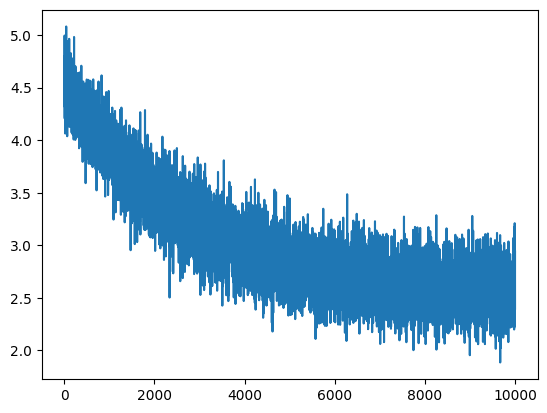

In [11]:
from tqdm import tqdm
import matplotlib.pyplot as plt

model = BigramLanguageModel(vocab_size)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
num_epochs = 10000
loss_list = []
for epoch_i in tqdm(range(num_epochs)):
    xb, yb = get_batch("train")

    logits, loss = model(xb, yb)
    loss_list.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

plt.plot(loss_list)

In [12]:
print(decode(model.generate(torch.zeros((1,1),dtype=torch.long), max_new_tokens=500)[0].tolist()))


y, 
J--Tne anta hil LUSherind the?gh ilely anvethepaupPulitons wathewave ousty; IKGckn ndqwarod spkeveles hil:
Asheesie, CKIo toke h seshevence ofusarenunke?&wougisavet. lat h,
WJubrauthe idamAno aserexp s gl, t me ben Wblld fr Jf athit lisandelo dolmeg buce h t n IIUSis aufrconr BE
Yo xtis, jpr,

il bXigndas d than, thisel toyowoupP: th;ncCUCZlererbaj.

Pl O:
d le

Tesetheere, Isd.

OAsth ar he,
E u,
p:
Tis touge lod by isy inyoutsona,

K:
PAsil ad hourd tous n's iovear-mowhen k tino;HO-?
Hobe 


## Self-attention

In [32]:
torch.manual_seed(42)
B, T, C = 4, 8, 32
x = torch.randn(B, T, C)

head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value =  nn.Linear(C, head_size, bias=False)
k = key(x) #B, T, 16
q = query(x) #B, T, 16
wei = q @ k.transpose(-2, -1) #B, T, 16 @ B, 16, T --> B, T, T 


tril = torch.tril(torch.ones(T, T))
# wei = torch.zeros((T, T))
wei = wei.masked_fill(tril==0, float("-inf"))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
# out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [33]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1905, 0.8095, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3742, 0.0568, 0.5690, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1288, 0.3380, 0.1376, 0.3956, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4311, 0.0841, 0.0582, 0.3049, 0.1217, 0.0000, 0.0000, 0.0000],
        [0.0537, 0.3205, 0.0694, 0.2404, 0.2568, 0.0592, 0.0000, 0.0000],
        [0.3396, 0.0149, 0.5165, 0.0180, 0.0658, 0.0080, 0.0373, 0.0000],
        [0.0165, 0.0375, 0.0144, 0.1120, 0.0332, 0.4069, 0.3136, 0.0660]],
       grad_fn=<SelectBackward0>)